# Audio Emotion Recognition with RAVDESS Dataset

This notebook trains a CNN model to classify emotions from audio using mel-spectrograms.

## 1. Installation and Imports

In [ ]:
!pip install torch torchaudio torchvision torchcodec librosa numpy matplotlib scikit-learn datasets tensorflow tqdm seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 17.2 MB/s eta 0:00:00


In [ ]:
import os
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from datasets import load_dataset
from tqdm import tqdm
import tensorflow as tf
from collections import Counter

## 2. Load Dataset

In [ ]:
dataset = load_dataset("xbgoose/ravdess")
print(dataset)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/669 [00:00<?, ?B/s]

data/train-00000-of-00002-94d632c9f1f51b(…):   0%|          | 0.00/167M [00:00<?, ?B/s]

data/train-00001-of-00002-bcaf733d4b46d6(…):   0%|          | 0.00/158M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1440 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['audio', 'modality', 'vocal_channel', 'emotion', 'emotional_intensity', 'statement', 'repetition', 'actor', 'gender'],
        num_rows: 1440
    })
})


## 3. Feature Extraction Functions

In [ ]:
def extract_mel_spectrogram(audio_array, sr, max_len=128, chunk_duration=3):
    """
    Convert audio into mel-spectrogram chunks with consistent normalization.

    Args:
        audio_array: Raw audio signal
        sr: Sampling rate
        max_len: Maximum length of spectrogram (time dimension)
        chunk_duration: Duration of each chunk in seconds

    Returns:
        Array of mel-spectrogram chunks
    """
    samples_per_chunk = int(chunk_duration * sr)
    mel_chunks = []

    for start in range(0, len(audio_array), samples_per_chunk // 2):
        end = start + samples_per_chunk
        chunk = audio_array[start:end]
        if len(chunk) < samples_per_chunk * 0.5:
            break

        mel_spec = librosa.feature.melspectrogram(
            y=chunk, sr=sr, n_mels=128, fmax=8000
        )
        mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

        # Use fixed normalization range
        mel_spec_db = (mel_spec_db + 80) / 80  # Normalize to [0, 1] range
        mel_spec_db = np.clip(mel_spec_db, 0, 1)  # Clip to valid range

        # Pad or cut to fixed size
        if mel_spec_db.shape[1] < max_len:
            pad_width = max_len - mel_spec_db.shape[1]
            mel_spec_db = np.pad(mel_spec_db, ((0, 0), (0, pad_width)), mode="constant")
        else:
            mel_spec_db = mel_spec_db[:, :max_len]

        mel_chunks.append(np.expand_dims(mel_spec_db, axis=-1))

    return np.array(mel_chunks)

## 4. Data Preparation

In [ ]:
print("🔄 Extracting features from dataset...")

X, y = [], []

for sample in tqdm(dataset["train"]):
    audio_array = sample["audio"]["array"]
    sr = sample["audio"]["sampling_rate"]

    chunks = extract_mel_spectrogram(audio_array, sr=sr)

    # Use only the first chunk for training (RAVDESS clips are short)
    mel_spec = chunks[0]
    X.append(mel_spec)
    y.append(sample["emotion"])

# Convert to arrays
X = np.array(X)
y = np.array(y)

print(f"✅ Feature tensor shape: {X.shape}")
print(f"✅ Labels shape: {y.shape}")

# Encode string labels to numbers
encoder = LabelEncoder()
y = encoder.fit_transform(y)
y = to_categorical(y)

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"✅ Training set: {X_train.shape}, Testing set: {X_test.shape}")
print(f"✅ Emotion classes: {encoder.classes_}")

🔄 Extracting features from dataset...


100%|██████████| 1440/1440 [01:31<00:00, 15.74it/s]


✅ Feature tensor shape: (1440, 128, 128, 1)
✅ Labels shape: (1440,)
✅ Training set: (1152, 128, 128, 1), Testing set: (288, 128, 128, 1)
✅ Emotion classes: ['angry' 'calm' 'disgust' 'fearful' 'happy' 'neutral' 'sad' 'surprised']


## 5. Model Architecture

In [ ]:
def build_emotion_model(input_shape=(128, 128, 1), num_classes=8):
    """
    Build a CNN model for emotion classification from mel-spectrograms.

    Architecture:
    - 4 Convolutional blocks with BatchNorm and Dropout
    - 2 Dense layers with regularization
    - Softmax output for multi-class classification
    """
    model = models.Sequential([
        # Block 1
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Block 2
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Block 3
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Block 4
        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Dense layers
        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

# Create and compile model
model = build_emotion_model(input_shape=(128, 128, 1), num_classes=len(encoder.classes_))
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ Model built!")
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


✅ Model built!


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 9,701,096 (37.01 MB)

 Trainable params: 9,697,640 (36.99 MB)

 Non-trainable params: 3,456 (13.50 KB)

## 6. Training Configuration

In [ ]:
# Configure callbacks
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        'best_emotion_model.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

print("✅ Callbacks configured!")

✅ Callbacks configured!


## 7. Model Training

In [ ]:
print("🚀 Starting training...")
print(f"Training samples: {len(X_train)}")
print(f"Validation samples: {len(X_test)}")
print(f"Number of emotion classes: {len(encoder.classes_)}")
print(f"Emotion classes: {encoder.classes_}")

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

print("✅ Training completed!")

🚀 Starting training...
Training samples: 1152
Validation samples: 288
Number of emotion classes: 8
Emotion classes: ['angry' 'calm' 'disgust' 'fearful' 'happy' 'neutral' 'sad' 'surprised']
Epoch 1/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.1561 - loss: 3.2466
Epoch 1: val_accuracy improved from -inf to 0.11806, saving model to best_emotion_model.h5


36/36 ━━━━━━━━━━━━━━━━━━━━ 28s 147ms/step - accuracy: 0.1568 - loss: 3.2425 - val_accuracy: 0.1181 - val_loss: 2.6753 - learning_rate: 0.0010
Epoch 2/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.2389 - loss: 2.6228
Epoch 2: val_accuracy improved from 0.11806 to 0.13194, saving model to best_emotion_model.h5


36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - accuracy: 0.2385 - loss: 2.6235 - val_accuracy: 0.1319 - val_loss: 2.8405 - learning_rate: 0.0010
Epoch 3/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.2223 - loss: 2.4424
Epoch 3: val_accuracy did not improve from 0.13194
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - accuracy: 0.2230 - loss: 2.4414 - val_accuracy: 0.1181 - val_loss: 4.0063 - learning_rate: 0.0010
Epoch 4/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.2594 - loss: 2.3571
Epoch 4: val_accuracy did not improve from 0.13194
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - accuracy: 0.2595 - loss: 2.3560 - val_accuracy: 0.1181 - val_loss: 5.3695 - learning_rate: 0.0010
Epoch 5/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.2706 - loss: 2.3449
Epoch 5: val_accuracy improved from 0.13194 to 0.13542, saving model to best_emotion_model.h5


36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - accuracy: 0.2701 - loss: 2.3438 - val_accuracy: 0.1354 - val_loss: 4.3469 - learning_rate: 0.0010
Epoch 6/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.2609 - loss: 2.2244
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 6: val_accuracy did not improve from 0.13542
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - accuracy: 0.2610 - loss: 2.2238 - val_accuracy: 0.1354 - val_loss: 6.8078 - learning_rate: 0.0010
Epoch 7/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.3379 - loss: 2.0641
Epoch 7: val_accuracy improved from 0.13542 to 0.14236, saving model to best_emotion_model.h5


36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - accuracy: 0.3376 - loss: 2.0637 - val_accuracy: 0.1424 - val_loss: 4.9860 - learning_rate: 5.0000e-04
Epoch 8/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.3438 - loss: 1.9218
Epoch 8: val_accuracy did not improve from 0.14236
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - accuracy: 0.3444 - loss: 1.9202 - val_accuracy: 0.1354 - val_loss: 3.0914 - learning_rate: 5.0000e-04
Epoch 9/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.3153 - loss: 1.8879
Epoch 9: val_accuracy did not improve from 0.14236
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - accuracy: 0.3160 - loss: 1.8870 - val_accuracy: 0.1215 - val_loss: 2.6852 - learning_rate: 5.0000e-04
Epoch 10/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.3600 - loss: 1.8237
Epoch 10: val_accuracy did not improve from 0.14236
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - accuracy: 0.3604 - loss: 1.8232 - val_accuracy: 0.1181 - val_loss: 2.8482 - learning_rate: 5.0000e-04
Epoch 11/50
36

## 8. Visualization Functions

In [ ]:
try:
    from google.colab import files
    print("📤 Click 'Choose Files' to upload your audio file...")
    uploaded = files.upload()
    audio_path = list(uploaded.keys())[0]
    print(f"✅ Uploaded: {audio_path}")
    predict_emotion_from_file(audio_path)
except ImportError:
    print("⚠️ Not running in Google Colab. Use Method 2 below.")

📤 Click 'Choose Files' to upload your audio file...


Saving audio (2).wav to audio (2).wav
✅ Uploaded: audio (2).wav
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step

🎭 Predicted Emotion: fearful
📊 Confidence: 43.63%

📈 All probabilities:
  angry: 17.80%
  calm: 0.71%
  disgust: 5.69%
  fearful: 43.63%
  happy: 5.03%
  neutral: 3.30%
  sad: 14.41%
  surprised: 9.44%


## 9. Model Evaluation

In [ ]:
# Make predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Classification report
print("\n📊 Classification Report:")
print(classification_report(y_true_classes, y_pred_classes, target_names=encoder.classes_))

# Confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)
print("\n🔢 Confusion Matrix:")
print(cm)

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step

📊 Classification Report:
              precision    recall  f1-score   support

       angry       0.00      0.00      0.00        36
        calm       0.00      0.00      0.00        44
     disgust       0.00      0.00      0.00        39
     fearful       0.12      1.00      0.21        34
       happy       0.00      0.00      0.00        41
     neutral       0.00      0.00      0.00        20
         sad       0.00      0.00      0.00        34
   surprised       0.00      0.00      0.00        40

    accuracy                           0.12       288
   macro avg       0.01      0.12      0.03       288
weighted avg       0.01      0.12      0.02       288


🔢 Confusion Matrix:
[[ 0  0  0 36  0  0  0  0]
 [ 0  0  0 44  0  0  0  0]
 [ 0  0  0 39  0  0  0  0]
 [ 0  0  0 34  0  0  0  0]
 [ 0  0  0 41  0  0  0  0]
 [ 0  0  0 20  0  0  0  0]
 [ 0  0  0 34  0  0  0  0]
 [ 0  0  0 40  0  0  0  0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


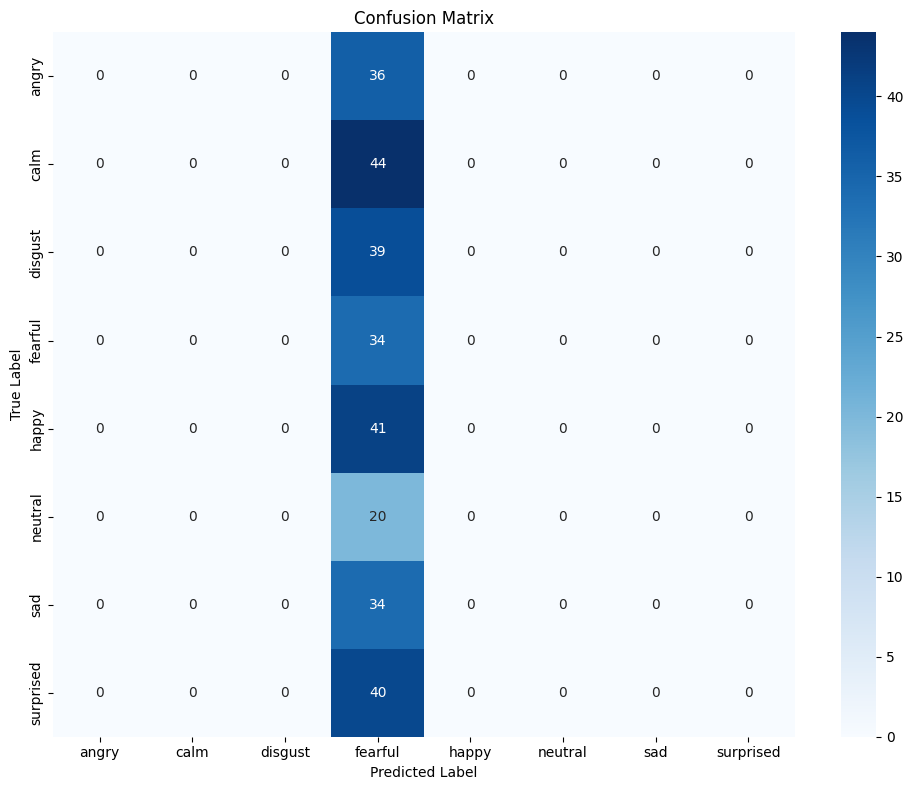

In [ ]:
# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=encoder.classes_,
            yticklabels=encoder.classes_)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

## 10. Prediction Functions

In [ ]:
def predict_emotion_from_file(audio_path):
    """
    Predict emotion from an audio file.

    Args:
        audio_path: Path to audio file

    Returns:
        Predicted emotion and confidence scores
    """
    # Load audio
    audio_array, sr = librosa.load(audio_path, sr=None)

    # Extract features using the same preprocessing
    chunks = extract_mel_spectrogram(audio_array, sr=sr)
    mel_spec = chunks[0]

    # Predict
    prediction = model.predict(np.expand_dims(mel_spec, axis=0))
    predicted_class = np.argmax(prediction)
    predicted_emotion = encoder.classes_[predicted_class]
    confidence = prediction[0][predicted_class]

    print(f"\n🎭 Predicted Emotion: {predicted_emotion}")
    print(f"📊 Confidence: {confidence:.2%}")
    print("\n📈 All probabilities:")
    for i, emotion in enumerate(encoder.classes_):
        print(f"  {emotion}: {prediction[0][i]:.2%}")

    return predicted_emotion, prediction[0]

## 11. Test Predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step

🎯 Test Sample #282
True Emotion: neutral
Predicted Emotion: fearful
Confidence: 43.82%


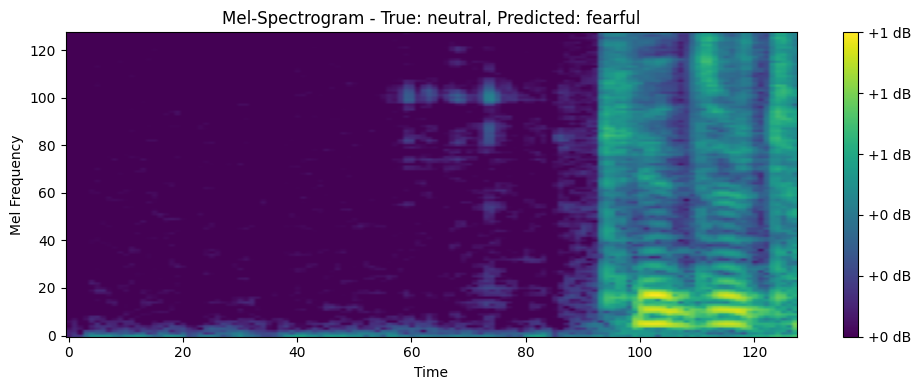

In [ ]:
# Test on a random sample from validation set
sample_idx = np.random.randint(0, len(X_test))
sample_audio = X_test[sample_idx:sample_idx+1]
sample_label = y_test[sample_idx]

prediction = model.predict(sample_audio)
predicted_class = np.argmax(prediction)
true_class = np.argmax(sample_label)

print(f"\n🎯 Test Sample #{sample_idx}")
print(f"True Emotion: {encoder.classes_[true_class]}")
print(f"Predicted Emotion: {encoder.classes_[predicted_class]}")
print(f"Confidence: {prediction[0][predicted_class]:.2%}")

# Visualize the mel-spectrogram
plt.figure(figsize=(10, 4))
plt.imshow(sample_audio[0, :, :, 0], aspect='auto', origin='lower', cmap='viridis')
plt.colorbar(format='%+2.0f dB')
plt.title(f'Mel-Spectrogram - True: {encoder.classes_[true_class]}, Predicted: {encoder.classes_[predicted_class]}')
plt.xlabel('Time')
plt.ylabel('Mel Frequency')
plt.tight_layout()
plt.show()